In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn.preprocessing
import matplotlib.pyplot as plt
%matplotlib inline


In [26]:
df=pd.read_excel('PS_10th_.xlsx')

In [27]:
df.head()

,Year,Topic_id,Topic,Appeared,Chapter_Name
0,2025,1,The Governament of Zulfiqar Ali Bhutto(1971-1977),0,History of Pakisatn-II
1,2025,2,Reforms Undertaken by Bhutto Governament,1,History of Pakisatn-II
2,2025,3,The 1973 Constitution,1,History of Pakisatn-II
3,2025,4,Basic Principles of State Policy,0,History of Pakisatn-II
4,2025,5,Islamic Provisonsof Constitution of 1973,0,History of Pakisatn-II


In [28]:
df['Chapter_Name'].unique()

array(['History of Pakisatn-II', 'Pakistan in Worlds Affairs',
       'Economic Development',
       'Population,Society and Culture of Pakistan'], dtype=object)

In [29]:
df.isnull().sum()

Year            0
Topic_id        0
Topic           0
Appeared        0
Chapter_Name    0
dtype: int64

In [30]:
chapter_weight_map = {
    'History of Pakisatn-II':                    0.30,
    'Pakistan in Worlds Affairs':                 0.15,
    'Economic Development':                       0.34,
    'Population,Society and Culture of Pakistan': 0.21,
}

In [31]:
df['chapter_weight'] = df['Chapter_Name'].map(chapter_weight_map)

In [32]:
df.isnull().sum()

Year              0
Topic_id          0
Topic             0
Appeared          0
Chapter_Name      0
chapter_weight    0
dtype: int64

In [33]:
df = df.sort_values(['Topic', 'Year']).reset_index(drop=True)


In [34]:
available_years = sorted(df['Year'].unique())

gaps = []
last_idx_appeared = {}
for _, row in df.iterrows():
    exercise = row['Topic']
    year = row['Year']
    appeared = row['Appeared']
    
    current_idx = available_years.index(year)
    
    if exercise not in last_idx_appeared:
        gaps.append(-1)
    else:
        gaps.append(current_idx - last_idx_appeared[exercise])
    
    if appeared == 1:
        last_idx_appeared[exercise] = current_idx

df['Gaps'] = gaps

In [35]:
years_in_data = df['Year'].unique()

frequency = []

for _, row in df.iterrows():
    topic = row['Topic']
    year = row['Year']
    
    # Pichle 5 available years nikalo (current year se pehle)
    prev_years = [y for y in years_in_data if y < year]
    last_5_years = prev_years[-5:]
    
    # Us topic ki un years mein appeared values nikalo
    topic_data = df[df['Topic'] == topic]
    count = topic_data[topic_data['Year'].isin(last_5_years)]['Appeared'].sum()
    
    frequency.append(int(count))

df['Frequency_Last_5'] = frequency

In [36]:
df['Appeared_last_year'] = df.groupby('Topic')['Appeared'].shift(1).fillna(0).astype(int)

In [37]:
df['rolling_3'] = (df.groupby('Topic')['Appeared']
                   .transform(lambda x: x.shift(1).rolling(3).sum())
                   .fillna(0))

In [38]:
df.isnull().sum()

Year                  0
Topic_id              0
Topic                 0
Appeared              0
Chapter_Name          0
chapter_weight        0
Gaps                  0
Frequency_Last_5      0
Appeared_last_year    0
rolling_3             0
dtype: int64

In [39]:
df_model=df.copy()

## Train Test Split
Here we'll experiment to check how well our model understands pattern that's why we train data on ```2024,2023,2022,2019,2018,2017,2016``` and test on the paper of ```2025```

In [40]:
train = df_model[df_model['Year'] < 2025]
test  = df_model[df_model['Year'] == 2025]

features = ['Gaps', 'Frequency_Last_5','Appeared_last_year','rolling_3','chapter_weight']
targets = 'Appeared'

X_train = train[features]
y_train = train[targets]

X_test = test[features]
y_test = test[targets]

## Baseline Model
  ### ***. LogisticRegression***

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [42]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

### Accuracy , Precision , Recall

In [43]:
from sklearn.metrics import accuracy_score,precision_score,recall_score
y_prob_lr = pipe.predict_proba(X_test)[:, 1]
accuracy_lr = accuracy_score(y_test, y_pred)
precision_lr = precision_score(y_test, y_pred)
recall_lr = recall_score(y_test, y_pred)
print(f"Accuracy:  {accuracy_lr * 100:.2f}%")
print(f'Precision:{precision_lr*100:.2f}%')
print(f'Recall:{recall_lr*100:.2f}%')

Accuracy:  78.18%
Precision:65.62%
Recall:95.45%


## Dummy Classifier

In [44]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print(f"Dummy Accuracy: {accuracy_score(y_test, dummy.predict(X_test)):.4f}")

Dummy Accuracy: 0.6000


### Accuarcy , Classification Report On Different Threshold

In [45]:
from sklearn.metrics import classification_report

y_prob_lr = pipe.predict_proba(X_test)[:, 1]

for threshold in [0.5, 0.4, 0.3, 0.25]:
    y_pred_thresh = (y_prob_lr >= threshold).astype(int)
    print(f'Accuracy:{accuracy_score(y_test,y_pred_thresh)*100:.2f}%')
    print(f"\nThreshold={threshold}")
    print(classification_report(y_test, y_pred_thresh))

Accuracy:78.18%

Threshold=0.5
              precision    recall  f1-score   support

           0       0.96      0.67      0.79        33
           1       0.66      0.95      0.78        22

    accuracy                           0.78        55
   macro avg       0.81      0.81      0.78        55
weighted avg       0.84      0.78      0.78        55

Accuracy:60.00%

Threshold=0.4
              precision    recall  f1-score   support

           0       1.00      0.33      0.50        33
           1       0.50      1.00      0.67        22

    accuracy                           0.60        55
   macro avg       0.75      0.67      0.58        55
weighted avg       0.80      0.60      0.57        55

Accuracy:40.00%

Threshold=0.3
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        33
           1       0.40      1.00      0.57        22

    accuracy                           0.40        55
   macro avg       0.20      0.50  

c:\Users\aliah\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aliah\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aliah\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

### Prediction For 2026

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Step 1 - Full data pe train karo
features = ['Gaps', 'Frequency_Last_5', 'Appeared_last_year', 'rolling_3', 'chapter_weight']
targets = 'Appeared'

X_full = df_model[features].copy()
y_full = df_model[targets]

pipe_full = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
pipe_full.fit(X_full, y_full)

# Step 2 - 2026 ka base
df_2026 = df[df['Year'] == 2025][['Topic_id', 'Topic', 'Chapter_Name', 'Appeared', 'Gaps',
              'Frequency_Last_5', 'Appeared_last_year',
              'rolling_3', 'chapter_weight']].copy()
df_2026['Year'] = 2026

# Step 3 - Features update
df_2026['Appeared_last_year'] = df_2026['Appeared']
df_2026['Gaps'] = df_2026.apply(
    lambda row: 1 if row['Appeared'] == 1 else row['Gaps'] + 1, axis=1)
df_2026['Frequency_Last_5'] = df_2026.apply(
    lambda row: min(5, row['Frequency_Last_5'] + row['Appeared']), axis=1)
df_2026['rolling_3'] = df_2026.apply(
    lambda row: min(3, row['rolling_3'] + row['Appeared']), axis=1)

# Step 4 - Predict
X_2026 = df_2026[features].copy()
prob_2026 = pipe_full.predict_proba(X_2026)[:, 1]
df_2026['Probability'] = prob_2026

# Step 5 - Filter + Category
result_2026 = df_2026[['Topic_id', 'Topic', 'Chapter_Name', 'Probability']]\
              .sort_values('Probability', ascending=False)\
              .reset_index(drop=True)

final_predictions = result_2026[result_2026['Probability'] >= 0.5].head(25).copy()

final_predictions['Category'] = final_predictions['Probability'].apply(
    lambda x: 'A - Must Prepare' if x >= 0.7 else 'B - Should Prepare'
)

# Step 6 - Years appeared nikalo
appeared_years_list = []
for _, row in final_predictions.iterrows():
    topic = row['Topic']
    years = df[
        (df['Topic'] == topic) &
        (df['Appeared'] == 1)
    ]['Year'].tolist()
    appeared_years_list.append(', '.join(map(str, sorted(years))))

final_predictions['Years_Appeared'] = appeared_years_list
final_predictions['Total_Appearances'] = final_predictions['Years_Appeared'].apply(
    lambda x: len(x.split(', ')) if x else 0
)

# Step 7 - Save
final_predictions.to_excel('PS_10TH_Predictions_2026.xlsx', index=False)
print(final_predictions)

    Topic_id                                              Topic  \
0         54                           The language of Pakistan   
1          2           Reforms Undertaken by Bhutto Governament   
2         12           Governament of Benazir Bhutto(1988-1990)   
3         11            The Governament of Muhammad khan Junejo   
4         35                                  Mineral Resources   
5         33                   Pakistan's Role in United Nation   
6         27                            Central Asain Republics   
7         30                                              SAARC   
8         14        Governament of Mian Nawaz Sharif(1990-1993)   
9          3                              The 1973 Constitution   
10        45                                            Poverty   
11        46                             Pakistan's Major Ports   
12        39                                Means of Irrigation   
13        26               Relation with Neighbouring Countrie

In [47]:
result_2026['Category'] = result_2026['Probability'].apply(
    lambda x: 'A - Must Prepare' if x >= 0.85 else 
              ('B - Should Prepare' if x >= 0.80 else 'C - Optional')
)
print(result_2026)

    Topic_id                                              Topic  \
0         54                           The language of Pakistan   
1          2           Reforms Undertaken by Bhutto Governament   
2         12           Governament of Benazir Bhutto(1988-1990)   
3         11            The Governament of Muhammad khan Junejo   
4         35                                  Mineral Resources   
5         33                   Pakistan's Role in United Nation   
6         27                            Central Asain Republics   
7         30                                              SAARC   
8         14        Governament of Mian Nawaz Sharif(1990-1993)   
9          3                              The 1973 Constitution   
10        45                                            Poverty   
11        46                             Pakistan's Major Ports   
12        39                                Means of Irrigation   
13        26               Relation with Neighbouring Countrie

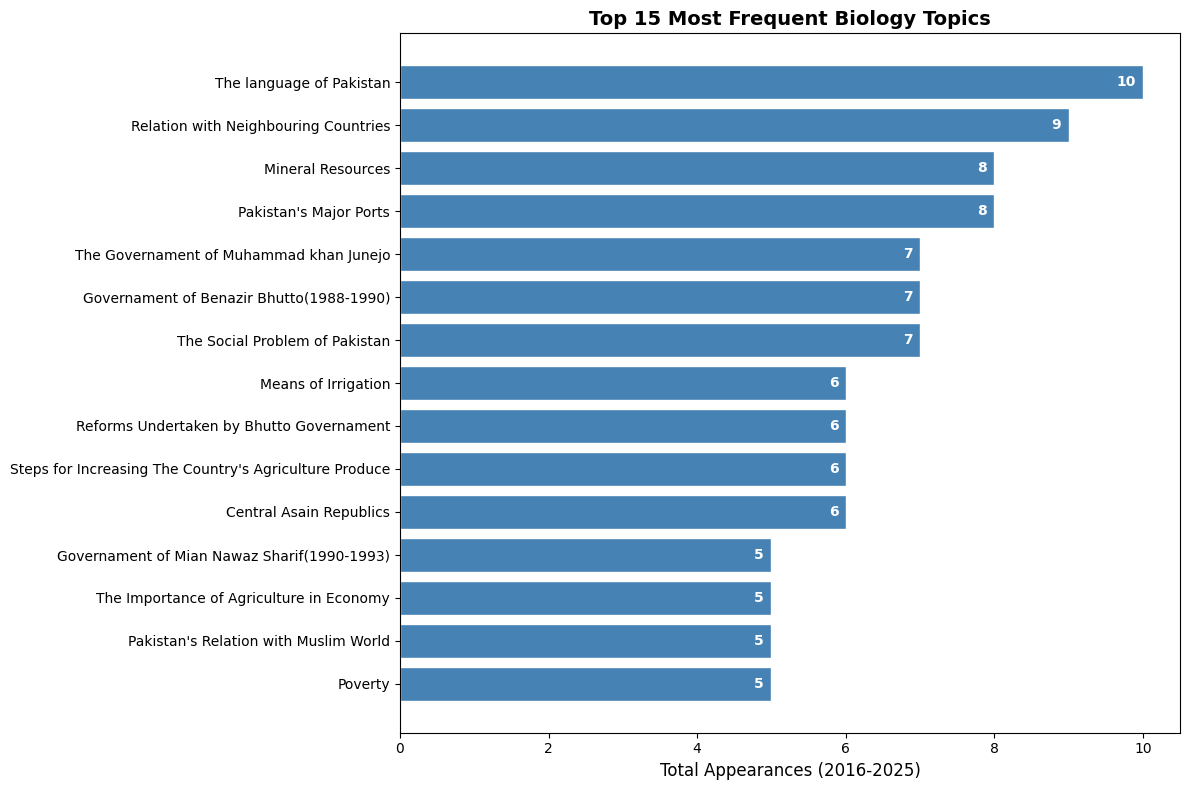

In [48]:
import matplotlib.pyplot as plt

topic_freq = df.groupby('Topic')['Appeared'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(topic_freq.index, topic_freq.values, color='steelblue', edgecolor='white')
plt.xlabel('Total Appearances (2016-2025)', fontsize=12)
plt.title('Top 15 Most Frequent Biology Topics', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Values bar ke andar dikhao
for bar, val in zip(bars, topic_freq.values):
    plt.text(val - 0.1, bar.get_y() + bar.get_height()/2, 
             str(int(val)), va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('graph1_frequency.png', dpi=150)
plt.show()

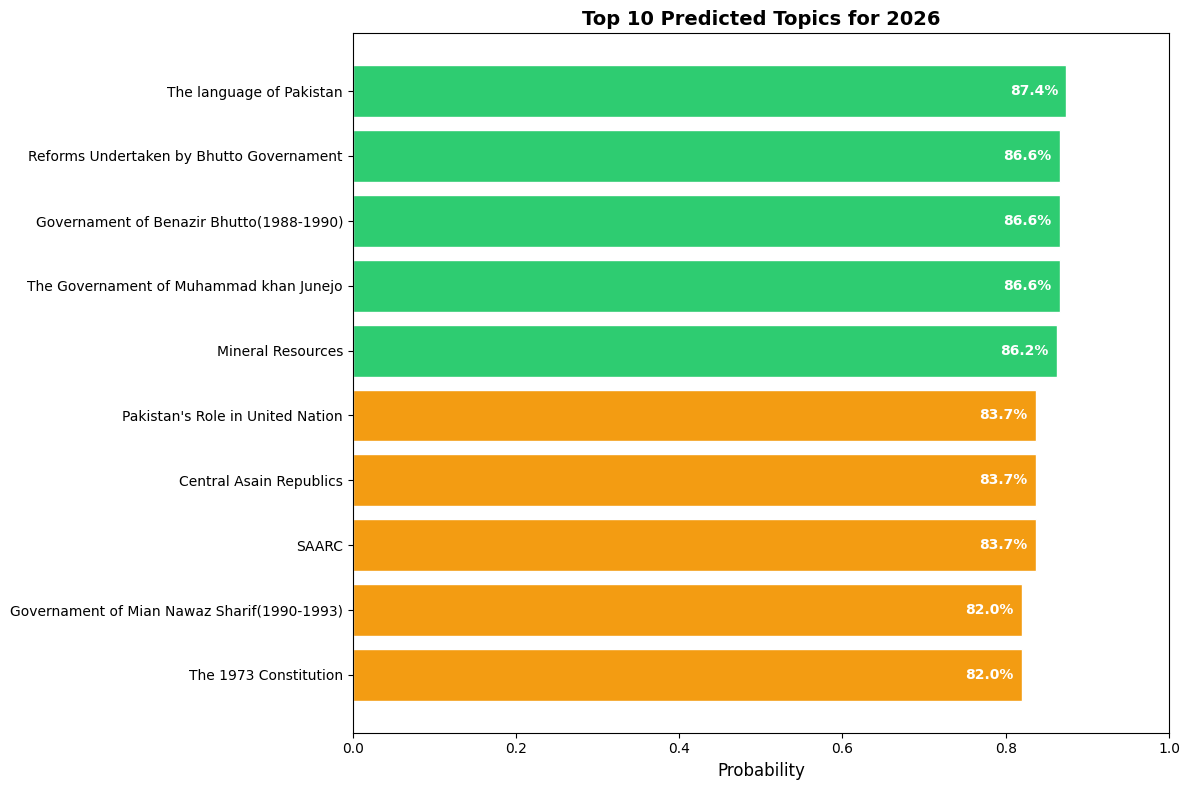

In [49]:
top10 = result_2026.head(10)

plt.figure(figsize=(12, 8))
colors = ['#2ecc71' if p >= 0.85 else '#f39c12' if p >= 0.80 else '#e74c3c' 
          for p in top10['Probability']]
bars = plt.barh(top10['Topic'], top10['Probability'], color=colors, edgecolor='white')
plt.xlabel('Probability', fontsize=12)
plt.title('Top 10 Predicted Topics for 2026', fontsize=14, fontweight='bold')
plt.xlim(0, 1)
plt.gca().invert_yaxis()

for bar, val in zip(bars, top10['Probability']):
    plt.text(val - 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.1%}', va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('graph2_predictions.png', dpi=150)
plt.show()